# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts:
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions.

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset).

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
import scipy.stats as stats
from numpy.random import seed
medical = pd.read_csv('/content/insurance2.csv')

In [2]:
medical.shape

(1338, 8)

In [3]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__

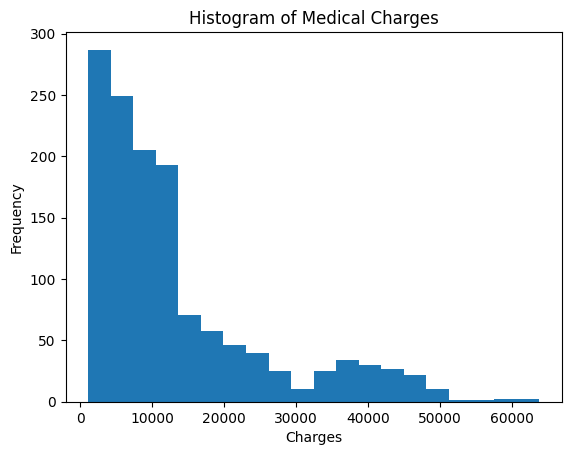

In [4]:
plt.hist(medical['charges'], bins=20)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Histogram of Medical Charges')
plt.show()

In [5]:
medical['charges'].mean()
print('Average of charges is', round(medical['charges'].mean(), 2))

Average of charges is 13270.42


In [6]:
medical['charges'].std()
print('Standard deviation of charges is', round(medical['charges'].std(), 2))

Standard deviation of charges is 12110.01


In [7]:
# Medical charges distribution is not Normal, and the distribution is right-skewed.
# However, distribution of the sample means will be normally distributed because sample size is pretty large.

In [8]:
medical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   int64  
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   int64  
 5   region          1338 non-null   int64  
 6   charges         1338 non-null   float64
 7   insuranceclaim  1338 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 83.8 KB


__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

In [9]:
# Since sample size is sufficiently large, we can say our sample means are normally distributed even we know our samples are right-skewed and not normally distributed.
# Therefore, We can calculate 95% Confidence Interval to check if real population mean lies inside the interval.

__A:__

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

In [10]:
# I am going to pick a two-sided confidence interval.

__A:__

In [11]:
# In order to calculate confidence interval we need to have items below:
# sample mean = 13270
# sample standard deviatoion = 12110
# sample size = 1338
# The level of confidence = 95%
# Standard Error = sample std / sqrt(sample size)
# degree of freedom = 1338 - 1 = 1337
# t-value from t-table = 1.9617

# degree of freedom is 1337, and confidence is 95%.
#Therefore, based on t-table, the t-value will be 1.9617

In [12]:
# Calculating the Standard Error (SE):

SE = medical['charges'].std() / np.sqrt(medical['charges'].count())
print('Standard Error is', SE)

Standard Error is 331.06745431568226


In [13]:
# Finding t-value from t-tble:
# t-value is 1.96

In [14]:
# Calculate the margin of error (ME):
# ME = t-value * SE
ME = 1.96 * 331.06
print('Margin of Error is', ME)

Margin of Error is 648.8776


In [15]:
# Determine the confidence interval
# Lower Limit = sample mean - ME
# Upper Limit = sample mean + ME

Lower_Limit = medical['charges'].mean() - ME
Upper_Limit = medical['charges'].mean() + ME

print('Lower Limit is', Lower_Limit)
print('Upper Limit is', Upper_Limit)

Lower Limit is 12621.544665141257
Upper Limit is 13919.299865141256


In [16]:
# Conclusion & Result:

# We are 95% confident that the true population mean of medical charges lies between 12621.54 and 13919.299 .
# As the result, the administrator should NOT be concerned, because the minimum value for average charges is still above 12000$.


The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*).

What assumption about the variances of the two groups are we making here?

In [17]:
# We need to split our dateset into 2 separate sets. One for people with insurance, and one for those without insurance.
# t-statistics tells us if the difference between 2 sets are meaningful, or it is just because of randomness.
# t-statistic = Signal / Noise


In [18]:
# Null Hypothesis : There is no difference between medical charges whether the patient has insurance or not.
# Alternative Hypothesis : There is a difference between mediacl charges of patients with insurance, and patients without insurance.

# First, I subset the data for those who paid without insuarance. Then I calculate t-statistic for those and compare to dataset mean.
# Then I subset data for those who paid with insurance. Calculate t-statistc and compare to dataset's mean as well.

In [19]:
# mean of whole dataset charges:
all_charges_mean = medical['charges'].mean()
print(all_charges_mean)

13270.422265141257


In [20]:
# calculate mean() and std() for no insurance payments
no_insurance = medical[medical['insuranceclaim'] == 0]
no_insurance_mean = no_insurance['charges'].mean()
no_insurance_std = no_insurance['charges'].std()
print('payments without insurance mean is', no_insurance_mean)
print('payments without insurance std is', no_insurance_std)
print('number of charges is', no_insurance['charges'].count())

payments without insurance mean is 8821.421892306305
payments without insurance std is 6446.510126811736
number of charges is 555


In [22]:
# calculate mean() and std() for insurance payments
with_insurance = medical[medical['insuranceclaim'] == 1]
with_insurance_mean = with_insurance['charges'].mean()
with_insurance_std = with_insurance['charges'].std()
print('payments with insurance mean is', with_insurance_mean)
print('payments with insurance std is', with_insurance_std)
print('number of charges is', with_insurance['charges'].count())

payments with insurance mean is 16423.928276537677
payments with insurance std is 14045.928418802127
number of charges is 783


In [23]:

# Now, let's calculate t-statistic. I consider with_insurance's mean as the base and compare no_insurance against it:

#standard error of no_insurance:
SE = no_insurance_std / 555
print('SE is', SE)


# t-statistic = (  Mean(no_insurance) - Mean(with_insurance)  )  /   ( standard error of no_insurance )
t_statistic = ( no_insurance_mean - with_insurance_mean ) / SE
print('t-statistic is', t_statistic)

SE is 11.615333561822947
t-statistic is -654.5232940377315


In [24]:
# The difference between the means is pretty large. It is obvious patients with insurance are charged much more than patients without insurance.
# However, we do not know what type of services were received by patients without insurance. Maybe they received cheaper medications/treatments.

# Let's calculate t-statistic for no_insurance patients first.

SE_no = no_insurance_std / np.sqrt(medical['charges'].count())

t_statistic_no_insurance = (no_insurance_mean - medical['charges'].mean() ) / SE

print('t_statistic for no insurance patients is', t_statistic_no_insurance )

t_statistic for no insurance patients is -383.02820570369494


In [25]:
# Let's calculate t-statistics for with_insurance patietns:

SE_with = with_insurance_std / np.sqrt(medical['charges'].count())

t_statistic_with_insurance = (with_insurance_mean - medical['charges'].mean() ) / SE

print('t_statistic for with insurance patients is', t_statistic_with_insurance )


t_statistic for with insurance patients is 271.4950883340366


In [26]:
# All t-statistic values that I found are very big, which shows these two subsets (with and without insurance) are meaningfully different.
# So the Null Hypothesis is rejected and the Alternative Hypothesis is accepted.
# Therefore, patients pay differently based on having or not having insurance.

__A:__

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__

In [32]:
t_statistic_value = stats.ttest_ind(no_insurance, with_insurance)
print(t_statistic_value)

TtestResult(statistic=array([ -4.1838539 ,  -1.15432796, -15.21032286,  16.40772537,
       -12.91969193,  -0.76377764, -11.89329903,         -inf]), pvalue=array([3.05313660e-05, 2.48572176e-01, 2.62817401e-48, 2.93688812e-55,
       4.56529702e-36, 4.45134623e-01, 4.46123023e-31, 0.00000000e+00]), df=array([1336., 1336., 1336., 1336., 1336., 1336., 1336., 1336.]))


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


In [33]:
# Not sure if the code above is correct.

Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

In [34]:
# No, you will not find a dedicated, end-to-end function for a sample-based z-test (like scipy.stats.ttest_1samp) inside the scipy.stats library.
# In real-world data science and research, a true z-test requires you to know the exact population standard deviation.
# If you are calculating the standard deviation directly from your sample, you should mathematically be using a t-test, which accounts for the extra uncertainty of estimating.
# Because knowing the true population variance is incredibly rare in practice, SciPy prioritizes the much more common t-test.


__A:__

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test